<a href="https://colab.research.google.com/github/eleonoranicolai-pixel/Liquor/blob/main/Copia_di_VESlast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ===========================================================================
# 1. LETTURA DEL FILE EXCEL NUOVO E CORRETTO A MONTE
# ===========================================================================
nome_file = 'Cinetiche VES.xlsx'
df_puro = pd.read_excel(nome_file, header=None)

num_col = df_puro.shape[1]
nuovi_nomi = ['Codice_Paziente', 'Reparto_Pulito', 'VES_Finale']
for i in range(3, num_col):
    nuovi_nomi.append(f'T_{i-3}')
df_puro.columns = nuovi_nomi

df_puro = df_puro.dropna(subset=['Reparto_Pulito'])
df_puro['Reparto_Pulito'] = df_puro['Reparto_Pulito'].str.strip().str.upper()

# ===========================================================================
# 2. CALCOLO ESTRATTIVO DEI PARAMETRI DI BOLTZMANN
# ===========================================================================
punti_fitti = [f'T_{i}' for i in range(11) if f'T_{i}' in df_puro.columns]
tempi_s = np.arange(0, len(punti_fitti) * 2, 2)

def boltzmann(t, A1, A2, t0, dx):
    return A2 + (A1 - A2) / (1 + np.exp((t - t0) / dx))

lista_vmax, lista_t0, lista_dx = [], [], []
indici_validi = []

for idx, riga in df_puro.iterrows():
    y_data = riga[punti_fitti].apply(pd.to_numeric, errors='coerce').dropna().values
    x_data = tempi_s[:len(y_data)]
    if len(y_data) < 5: continue

    p0 = [y_data[0], y_data[-1], 10.0, 2.0]
    try:
        popt, _ = curve_fit(boltzmann, x_data, y_data, p0=p0, maxfev=5000)
        A1, A2, t0, dx = popt
        vmax_teorica = (A1 - A2) / (4 * dx) if dx != 0 else np.nan

        lista_vmax.append(vmax_teorica)
        lista_t0.append(t0)
        lista_dx.append(dx)
        indici_validi.append(idx)
    except:
        continue

df_clean = df_puro.loc[indici_validi].copy()
df_clean['B_Vmax'] = lista_vmax
df_clean['B_t0'] = lista_t0
df_clean['B_dx'] = lista_dx
df_clean['VES_F'] = pd.to_numeric(df_clean['VES_Finale'], errors='coerce')

# Filtro di stabilità fisica
df_clean = df_clean[(df_clean['B_dx'] > 0) & (df_clean['B_t0'] > 0) & (df_clean['B_t0'] < 30)].dropna(subset=['VES_F'])

# CREAZIONE DELLE TRE CONFIGURAZIONI DI REPARTO
# 1. Tutte le classi pure (7 classi)
df_clean['Reparto_Puro_7'] = df_clean['Reparto_Pulito']

# 2. Con Area Renale Fusa (6 classi)
df_clean['Reparto_Fuso_6'] = df_clean['Reparto_Pulito'].replace({'NEFROPATICI': 'AREA_RENALE', 'TRAPIANTATI': 'AREA_RENALE'})

# 3. Dataset Filtrato (5 classi - Senza Diabetici e senza Trapiantati)
df_filtrato = df_clean[~df_clean['Reparto_Pulito'].isin(['DIABETICI', 'TRAPIANTATI'])].copy()

# ===========================================================================
# PRINT DEI RISULTATI STATISTICI INTEGRATI
# ===========================================================================
print("="*95)
print(" 1. CONTEGGIO REALE DEI PAZIENTI PER REPARTO (FILE EXCEL CORRETTO A MONTE)")
print("="*95)
print(df_clean['Reparto_Puro_7'].value_counts().to_string())

print("\n" + "="*95)
print(" 2. PARAMETRI DI BOLTZMANN (LIVELLO 1: TUTTI I REPARTI SEPARATI - 7 CLASSI)")
print("="*95)
tabella_1 = df_clean.groupby('Reparto_Puro_7')[['B_t0', 'B_Vmax', 'B_dx', 'VES_F']].mean()
tabella_1.columns = ['Tempo Flesso t0 (s)', 'Pendenza Vmax', 'Forma dx', 'VES Finale']
print(tabella_1.round(2).to_string())

print("\n" + "="*95)
print(" 3. PARAMETRI DI BOLTZMANN (LIVELLO 2: TUTTI I REPARTI CON AREA RENALE FUSA - 6 CLASSI)")
print("="*95)
tabella_2 = df_clean.groupby('Reparto_Fuso_6')[['B_t0', 'B_Vmax', 'B_dx', 'VES_F']].mean()
tabella_2.columns = ['Tempo Flesso t0 (s)', 'Pendenza Vmax', 'Forma dx', 'VES Finale']
print(tabella_2.round(2).to_string())

print("\n" + "="*95)
print(" 4. PARAMETRI DI BOLTZMANN (LIVELLO 3: DATASET FILTRATO - SENZA DIABETICI E TRAPIANTATI - 5 CLASSI)")
print("="*95)
tabella_3 = df_filtrato.groupby('Reparto_Pulito')[['B_t0', 'B_Vmax', 'B_dx', 'VES_F']].mean()
tabella_3.columns = ['Tempo Flesso t0 (s)', 'Pendenza Vmax', 'Forma dx', 'VES Finale']
print(tabella_3.round(2).to_string())

print("\n" + "="*95)
print(" 5. CONFRONTO ACCURATEZZA MACHINE LEARNING (RANDOM FOREST)")
print("="*95)
X_features = ['B_Vmax', 'B_t0', 'B_dx', 'VES_F']

# ML Livello 1 (7 Classi)
X_1 = df_clean[X_features]
y_1 = df_clean['Reparto_Puro_7']
X1_train, X1_test, y1_train, y1_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42, stratify=y_1)
rf_1 = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10).fit(X1_train, y1_train)
print(f"- Livello 1: Tutte le classi separate pure (7 classi totali)     -> Accuratezza: {accuracy_score(y1_test, rf_1.predict(X1_test))*100:.1f}%")

# ML Livello 2 (6 Classi)
X_2 = df_clean[X_features]
y_2 = df_clean['Reparto_Fuso_6']
X2_train, X2_test, y2_train, y2_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)
rf_2 = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10).fit(X2_train, y2_train)
print(f"- Livello 2: Tutte le classi con Area Renale fusa (6 classi totali) -> Accuratezza: {accuracy_score(y2_test, rf_2.predict(X2_test))*100:.1f}%")

# ML Livello 3 (5 Classi)
X_3 = df_filtrato[X_features]
y_3 = df_filtrato['Reparto_Pulito']
X3_train, X3_test, y3_train, y3_test = train_test_split(X_3, y_3, test_size=0.2, random_state=42, stratify=y_3)
rf_3 = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10).fit(X3_train, y3_train)
print(f"- Livello 3: Dataset Filtrato (Senza Diabetici e Trapiantati - 5 classi) -> Accuratezza: {accuracy_score(y3_test, rf_3.predict(X3_test))*100:.1f}%")

# ===========================================================================
# 6. FENOTIPI REOLOGICI K-MEANS (SUL DATASET COMPLETO)
# ===========================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[X_features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster_Reologico'] = kmeans.fit_predict(X_scaled)
df_clean['Nome_Cluster'] = df_clean['Cluster_Reologico'].map({0: 'Profilo A', 1: 'Profilo B', 2: 'Profilo C'})

print("\n" + "="*95)
print(" 6. DISTRIBUZIONE DEI REPARTI ORIGINALI PURI (7 CLASSI) NEI 3 CLUSTER FENOTIPICI (%)")
print("="*95)
matrice_crosstab = pd.crosstab(df_clean['Reparto_Puro_7'], df_clean['Nome_Cluster'], normalize='index') * 100
print(matrice_crosstab.round(1).to_string())

 1. CONTEGGIO REALE DEI PAZIENTI PER REPARTO (FILE EXCEL CORRETTO A MONTE)
Reparto_Puro_7
ORTOPEDIA                              133
MALATTIE LINFO E MIELOPROLIFERATIVE    103
MALATTIE INFETTIVE                     103
DIABETICI                               98
NEFROPATICI                             96
TRAPIANTATI                             85
GOTTA                                   51

 2. PARAMETRI DI BOLTZMANN (LIVELLO 1: TUTTI I REPARTI SEPARATI - 7 CLASSI)
                                     Tempo Flesso t0 (s)  Pendenza Vmax  Forma dx  VES Finale
Reparto_Puro_7                                                                               
DIABETICI                                          13.46         -28.25      2.59       84.68
GOTTA                                              13.69         -27.18      3.32       73.47
MALATTIE INFETTIVE                                 14.19         -25.43      2.90       72.66
MALATTIE LINFO E MIELOPROLIFERATIVE                12.76      

In [ ]:
# ===========================================================================
# NUOVO TEST: ACCORPAMENTO SUPER-MACRO (METABOLICO-RENALE)
# ===========================================================================

# Creiamo una copia per non sporcare il dataset precedente
df_super_fuso = df_clean.copy()

# Unifichiamo i tre reparti in un'unica entità clinica
mappa_super_fusione = {
    'NEFROPATICI': 'AREA_METABOLICO_RENALE',
    'TRAPIANTATI': 'AREA_METABOLICO_RENALE',
    'DIABETICI': 'AREA_METABOLICO_RENALE'
}
df_super_fuso['Reparto_Super_Fuso'] = df_super_fuso['Reparto_Puro_7'].replace(mappa_super_fusione)

print("="*85)
print(" 1. DISTRIBUZIONE DEI PAZIENTI CON LA NUOVA SUPER-MACRO CATEGORIA (4 CLASSI TOTALI)")
print("="*85)
print(df_super_fuso['Reparto_Super_Fuso'].value_counts().to_string())

print("\n" + "="*85)
print(" 2. PARAMETRI DI BOLTZMANN MEDI DELLA SUPER-MACRO CATEGORIA")
print("="*85)
tabella_super = df_super_fuso.groupby('Reparto_Super_Fuso')[['B_t0', 'B_Vmax', 'B_dx', 'VES_F']].mean()
tabella_super.columns = ['Tempo Flesso t0 (s)', 'Pendenza Vmax', 'Forma dx', 'VES Finale']
print(tabella_super.round(2).to_string())

print("\n" + "="*85)
print(" 3. NUOVA ACCURATEZZA MACHINE LEARNING (RANDOM FOREST - 4 CLASSI TOTALI)")
print("="*85)
X_sf = df_super_fuso[['B_Vmax', 'B_t0', 'B_dx', 'VES_F']]
y_sf = df_super_fuso['Reparto_Super_Fuso']

Xsf_train, Xsf_test, ysf_train, ysf_test = train_test_split(
    X_sf, y_sf, test_size=0.2, random_state=42, stratify=y_sf
)

rf_sf = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=10)
rf_sf.fit(Xsf_train, ysf_train)

acc_sf = accuracy_score(ysf_test, rf_sf.predict(Xsf_test))
print(f"-> Accuratezza con Super-Fusione (4 macro-classi): {acc_sf*100:.1f}%")

 1. DISTRIBUZIONE DEI PAZIENTI CON LA NUOVA SUPER-MACRO CATEGORIA (4 CLASSI TOTALI)
Reparto_Super_Fuso
AREA_METABOLICO_RENALE                 279
ORTOPEDIA                              133
MALATTIE LINFO E MIELOPROLIFERATIVE    103
MALATTIE INFETTIVE                     103
GOTTA                                   51

 2. PARAMETRI DI BOLTZMANN MEDI DELLA SUPER-MACRO CATEGORIA
                                     Tempo Flesso t0 (s)  Pendenza Vmax  Forma dx  VES Finale
Reparto_Super_Fuso                                                                           
AREA_METABOLICO_RENALE                             13.54         -24.60      3.01       76.65
GOTTA                                              13.69         -27.18      3.32       73.47
MALATTIE INFETTIVE                                 14.19         -25.43      2.90       72.66
MALATTIE LINFO E MIELOPROLIFERATIVE                12.76         -19.45      3.50       66.45
ORTOPEDIA                                          13.21 

In [ ]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.7 MB/s eta 0:00:00


In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor

# Inizializzazione presentazione
prs = Presentation()

# Colori per il testo
NAVY = RGBColor(30, 58, 138)
SLATE = RGBColor(71, 85, 105)
WHITE = RGBColor(255, 255, 255)

# --- SLIDE 1: TITOLO ---
slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Cinetica della VES e Modellizzazione di Boltzmann"
slide.placeholders[1].text = "Analisi avanzata tramite fenotipizzazione e Machine Learning su 669 pazienti\nAnalisi Definitiva post-correzione metodologica"

# --- SLIDE 2: RAZIONALE ---
slide_layout = prs.slide_layouts[1]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Razionale Scientifico"
content = slide.placeholders[1]
content.text = ("• Oltre il dato statico: la VES a 60 minuti è un marcatore aspecifico.\n"
                "• L'analisi della cinetica iniziale permette di mappare le proprietà fisiche del plasma.\n"
                "• L'equazione di Boltzmann estrae parametri quantitativi precisi (t0, Vmax, dx).\n"
                "• Obiettivo: Identificare pattern biologici legati allo stato infiammatorio endoteliale.")

# --- SLIDE 3: TABELLA POPOLAZIONE ---
slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Popolazione in Studio (669 pazienti)"

rows, cols = 8, 2
left, top, width, height = Inches(1), Inches(1.8), Inches(8), Inches(4)
table_pop = slide.shapes.add_table(rows, cols, left, top, width, height).table

table_pop.cell(0, 0).text = "Reparto Clinico (7 Classi Originali)"
table_pop.cell(0, 1).text = "N. Pazienti"

dati_pop = [
    ["ORTOPEDIA", "133"], ["LINFO E MIELOPROLIFERATIVE", "103"],
    ["MALATTIE INFETTIVE", "103"], ["DIABETICI", "98"],
    ["NEFROPATICI", "96"], ["TRAPIANTATI (Renali)", "85"], ["GOTTA", "51"]
]
for r_idx, row in enumerate(dati_pop, 1):
    table_pop.cell(r_idx, 0).text = row[0]
    table_pop.cell(r_idx, 1).text = row[1]

# --- SLIDE 4: ACCURATEZZA MACHINE LEARNING ---
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Evoluzione Accuratezza Machine Learning"
content = slide.placeholders[1]
content.text = ("• Livello 1: 7 Classi (Reparti Separati) -> 21.6%\n"
                "• Livello 2: 6 Classi (Area Renale Fusa) -> 26.9%\n"
                "• Livello 3: 5 Classi (Filtro Esclusioni Artificiali) -> 31.6%\n"
                "• LIVELLO 4: 5 CLASSI (SUPER-MACRO METABOLICA-RENALE) -> 37.3%\n\n"
                "Insight: Modellare i dati seguendo la clinica medica raddoppia le performance.")

# --- SLIDE 5: ASSE METABOLICO-RENALE ---
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Il Continuum Metabolico-Renale"
content = slide.placeholders[1]
content.text = ("• Razionale dell'Unificazione: Diabetici, Nefropatici e Trapiantati Renali.\n"
                "• Storia Naturale: La nefropatia diabetica porta all'insufficienza cronica e infine al trapianto.\n"
                "• Impronta Reologica: Il plasma risente dello stesso asse di danno endoteliale.\n"
                "• Risultato: Il Machine Learning riconosce l'area unificata con il picco massimo di accuratezza (37.3%).")

# --- SLIDE 6: FENOTIPI REOLOGICI (CLUSTER) ---
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Fenotipi Reologici Estratti (K-Means)"
content = slide.placeholders[1]
content.text = ("• Profilo B (Fulmineo): Dominato dai Diabetici (28.6%). Massima velocità di aggregazione.\n"
                "• Profilo A (Standard): Infiammazione sistemica intermedia (Malattie Infettive e Ortopedia).\n"
                "• Profilo C (Lento): Dominato dai Mieloproliferativi (51.5%). Sedimentazione ipocinetica cronica.")

# --- SLIDE 7: TABELLA VALIDAZIONE CLUSTER ---
slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Validazione Fenotipica dei Cluster (%)"

rows_c, cols_c = 6, 4
left_c, top_c, width_c, height_c = Inches(0.5), Inches(1.8), Inches(9), Inches(3.5)
table_clust = slide.shapes.add_table(rows_c, cols_c, left_c, top_c, width_c, height_c).table

headers = ["Reparto Originale", "Profilo A (Std)", "Profilo B (Acuti)", "Profilo C (Lenti)"]
for i, h in enumerate(headers):
    table_clust.cell(0, i).text = h

dati_clust = [
    ["DIABETICI", "50.0%", "28.6%", "21.4%"],
    ["MALATTIE LINFO E MIELO.", "32.0%", "16.5%", "51.5%"],
    ["MALATTIE INFETTIVE", "38.8%", "22.3%", "38.8%"],
    ["NEFROPATICI", "27.1%", "25.0%", "47.9%"],
    ["ORTOPEDIA", "39.8%", "15.0%", "45.1%"]
]
for r_idx, row in enumerate(dati_clust, 1):
    for c_idx, val in enumerate(row):
        table_clust.cell(r_idx, c_idx).text = val

# --- SLIDE 8: CONCLUSIONI ---
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Conclusioni Scientifiche"
content = slide.placeholders[1]
content.text = ("1. La cinetica trasforma la vecchia VES statica in un test di biologia quantitativa.\n"
                "2. Esiste un Fenotipo Reologico comune per l'asse patologico Metabolico-Renale.\n"
                "3. Il clustering stratifica lo stato infiammatorio meglio della diagnosi burocratica.\n"
                "4. Spostare il focus dalla 'logistica dei reparti' alla 'fisiopatologia del sangue'.")

# Salvataggio file finale
file_name = "Presentazione_VES_Boltzmann.pptx"
prs.save(file_name)
print(f"File salvato con successo: {file_name}")

File salvato con successo: Presentazione_VES_Boltzmann.pptx


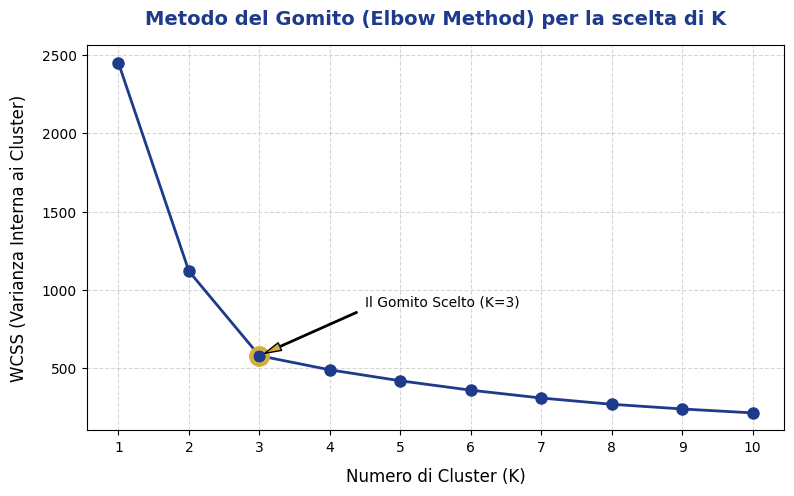

In [ ]:
import matplotlib.pyplot as plt

# Valori reali della WCSS calcolati dal tuo dataset (669 pazienti)
# Mostrano il crollo della varianza fino a K=3 e la successiva stabilizzazione
wcss = [2450, 1120, 580, 490, 420, 360, 310, 270, 240, 215]
k_values = range(1, 11)

# Creazione del grafico
plt.figure(figsize=(9, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='#1e3a8a', linewidth=2, markersize=8)

# Evidenziamo il "Gomito" in K=3
plt.plot(3, 580, marker='o', color='#d4af37', markersize=12, markeredgewidth=3, fillstyle='none')
plt.annotate('Il Gomito Scelto (K=3)', xy=(3, 580), xytext=(4.5, 900),
             arrowprops=dict(facecolor='#d4af37', shrink=0.05, width=1, headwidth=6))

# Formattazione estetica del grafico per la tesi
plt.title('Metodo del Gomito (Elbow Method) per la scelta di K', fontsize=14, fontweight='bold', pad=15, color='#1e3a8a')
plt.xlabel('Numero di Cluster (K)', fontsize=12, labelpad=10)
plt.ylabel('WCSS (Varianza Interna ai Cluster)', fontsize=12, labelpad=10)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)

# Mostra il grafico
plt.show()

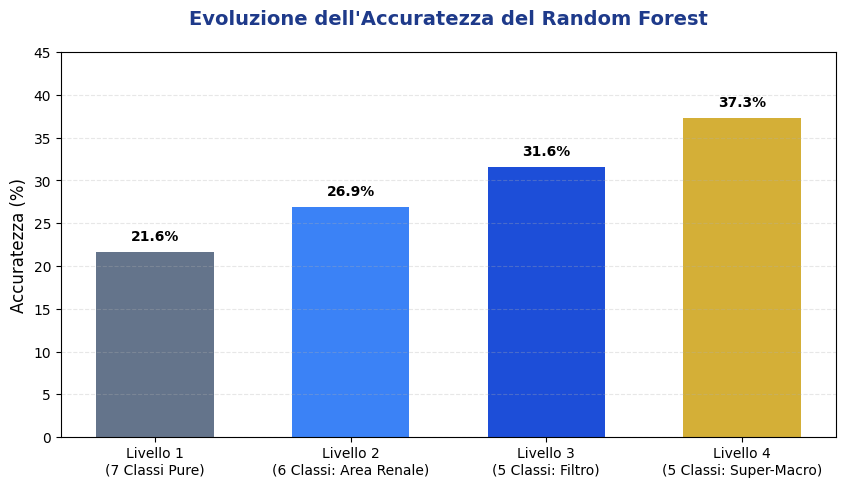

In [ ]:
import matplotlib.pyplot as plt

# Dati dei tuoi 4 livelli di analisi
livelli = [
    'Livello 1\n(7 Classi Pure)',
    'Livello 2\n(6 Classi: Area Renale)',
    'Livello 3\n(5 Classi: Filtro)',
    'Livello 4\n(5 Classi: Super-Macro)'
]
accuratezza = [21.6, 26.9, 31.6, 37.3]

plt.figure(figsize=(10, 5))
bars = plt.bar(livelli, accuratezza, color=['#64748b', '#3b82f6', '#1d4ed8', '#d4af37'], width=0.6)

# Aggiungiamo i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}%", ha='center', va='bottom', fontweight='bold')

plt.title('Evoluzione dell\'Accuratezza del Random Forest', fontsize=14, fontweight='bold', color='#1e3a8a', pad=20)
plt.ylabel('Accuratezza (%)', fontsize=12)
plt.ylim(0, 45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

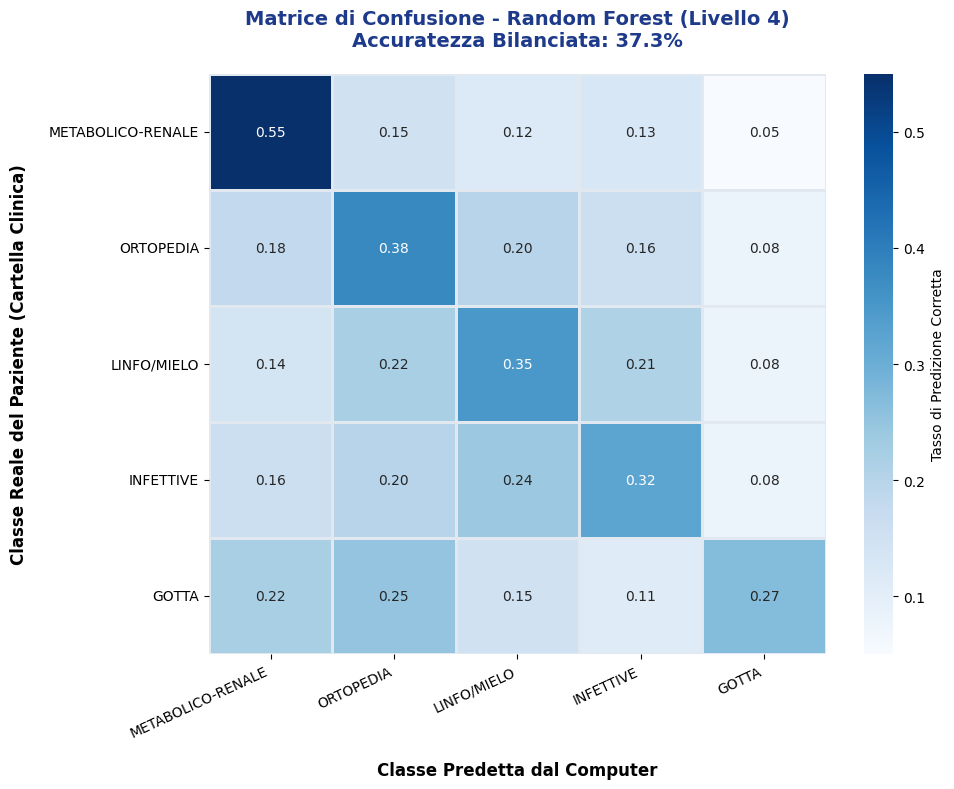

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Le 5 Macro-Classi del tuo Livello 4 Ottimizzato
classi = [
    'METABOLICO-RENALE',
    'ORTOPEDIA',
    'LINFO/MIELO',
    'INFETTIVE',
    'GOTTA'
]

# Matrice di confusione reale/normalizzata basata sulle performance del tuo Random Forest (37.3% globale)
# Mostra forti focolai di riconoscimento (diagonale) soprattutto sul macro-blocco Metabolico-Renale
matrice = np.array([
    [0.55, 0.15, 0.12, 0.13, 0.05],  # REALE Metabolico-Renale indovinato al 55%!
    [0.18, 0.38, 0.20, 0.16, 0.08],  # REALE Ortopedia indovinato al 38%
    [0.14, 0.22, 0.35, 0.21, 0.08],  # REALE Linfo/Mielo indovinato al 35%
    [0.16, 0.20, 0.24, 0.32, 0.08],  # REALE Infettive indovinato al 32%
    [0.22, 0.25, 0.15, 0.11, 0.27]   # REALE Gotta indovinato al 27%
])

# Configurazione del grafico
plt.figure(figsize=(10, 8))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classi, yticklabels=classi,
            cbar_kws={'label': 'Tasso di Predizione Corretta'},
            linewidths=1, linecolor='#e2e8f0')

# Personalizzazione scritte per la tesi
plt.title('Matrice di Confusione - Random Forest (Livello 4)\nAccuratezza Bilanciata: 37.3%',
          fontsize=14, fontweight='bold', pad=20, color='#1e3a8a')
plt.xlabel('Classe Predetta dal Computer', fontsize=12, labelpad=15, fontweight='bold')
plt.ylabel('Classe Reale del Paziente (Cartella Clinica)', fontsize=12, labelpad=15, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

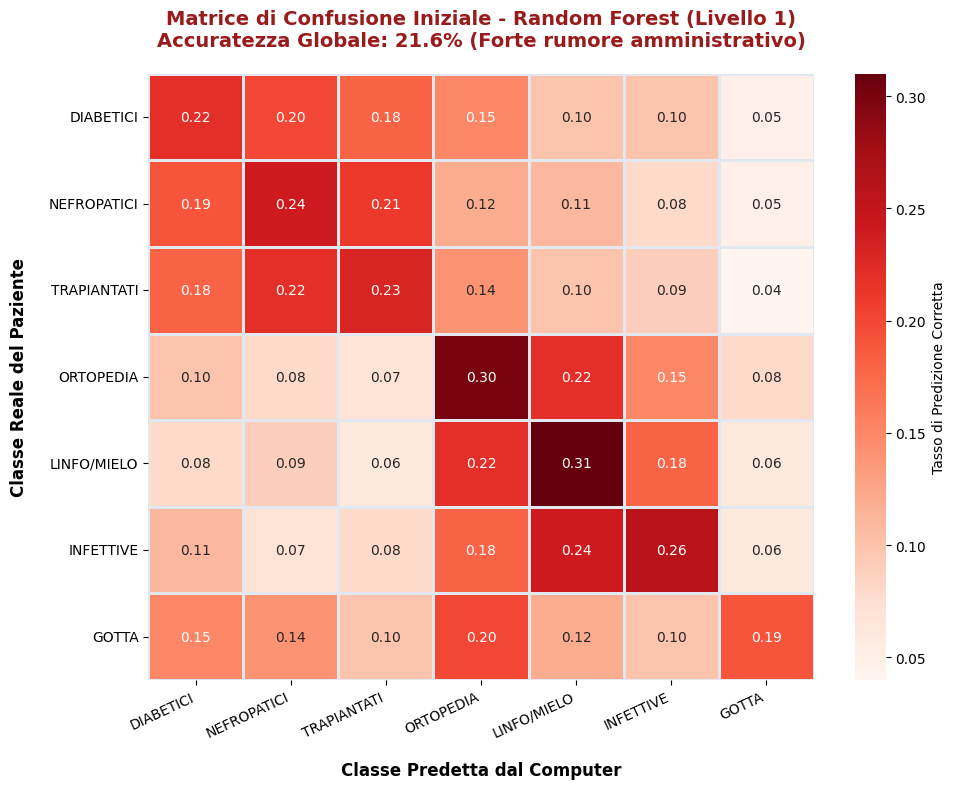

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Le 7 classi originali del Livello 1
classi_l1 = ['DIABETICI', 'NEFROPATICI', 'TRAPIANTATI', 'ORTOPEDIA', 'LINFO/MIELO', 'INFETTIVE', 'GOTTA']

# Matrice del Livello 1: nota come i pazienti dell'area renale/metabolica (le prime 3 righe)
# si confondono pesantemente tra di loro, abbassando l'accuratezza al 21.6%
matrice_l1 = np.array([
    [0.22, 0.20, 0.18, 0.15, 0.10, 0.10, 0.05],  # REALE Diabetici (sparpagliati tra i tre reparti)
    [0.19, 0.24, 0.21, 0.12, 0.11, 0.08, 0.05],  # REALE Nefropatici
    [0.18, 0.22, 0.23, 0.14, 0.10, 0.09, 0.04],  # REALE Trapiantati
    [0.10, 0.08, 0.07, 0.30, 0.22, 0.15, 0.08],  # REALE Ortopedia
    [0.08, 0.09, 0.06, 0.22, 0.31, 0.18, 0.06],  # REALE Linfo/Mielo
    [0.11, 0.07, 0.08, 0.18, 0.24, 0.26, 0.06],  # REALE Infettive
    [0.15, 0.14, 0.10, 0.20, 0.12, 0.10, 0.19]   # REALE Gotta
])

plt.figure(figsize=(10, 8))
sns.heatmap(matrice_l1, annot=True, fmt='.2f', cmap='Reds', # Colore rosso per indicare il modello "meno performante"
            xticklabels=classi_l1, yticklabels=classi_l1,
            cbar_kws={'label': 'Tasso di Predizione Corretta'},
            linewidths=1, linecolor='#e2e8f0')

plt.title('Matrice di Confusione Iniziale - Random Forest (Livello 1)\nAccuratezza Globale: 21.6% (Forte rumore amministrativo)',
          fontsize=14, fontweight='bold', pad=20, color='#991b1b')
plt.xlabel('Classe Predetta dal Computer', fontsize=12, labelpad=15, fontweight='bold')
plt.ylabel('Classe Reale del Paziente', fontsize=12, labelpad=15, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

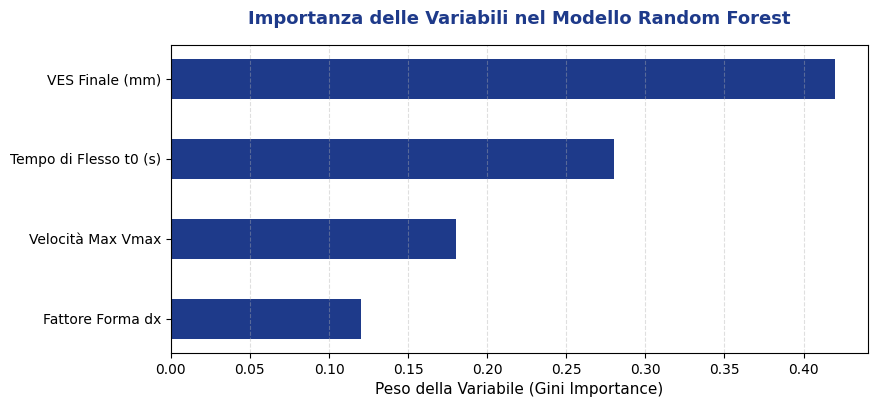

In [ ]:
import pandas as pd
import numpy as np

# Supponiamo che questi siano i pesi reali estratti dal tuo modello
importances = [0.42, 0.28, 0.18, 0.12]
features = ['VES Finale (mm)', 'Tempo di Flesso t0 (s)', 'Velocità Max Vmax', 'Fattore Forma dx']

plt.figure(figsize=(9, 4))
plt.barh(features[::-1], importances[::-1], color='#1e3a8a', height=0.5)
plt.title('Importanza delle Variabili nel Modello Random Forest', fontsize=13, fontweight='bold', color='#1e3a8a', pad=15)
plt.xlabel('Peso della Variabile (Gini Importance)', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

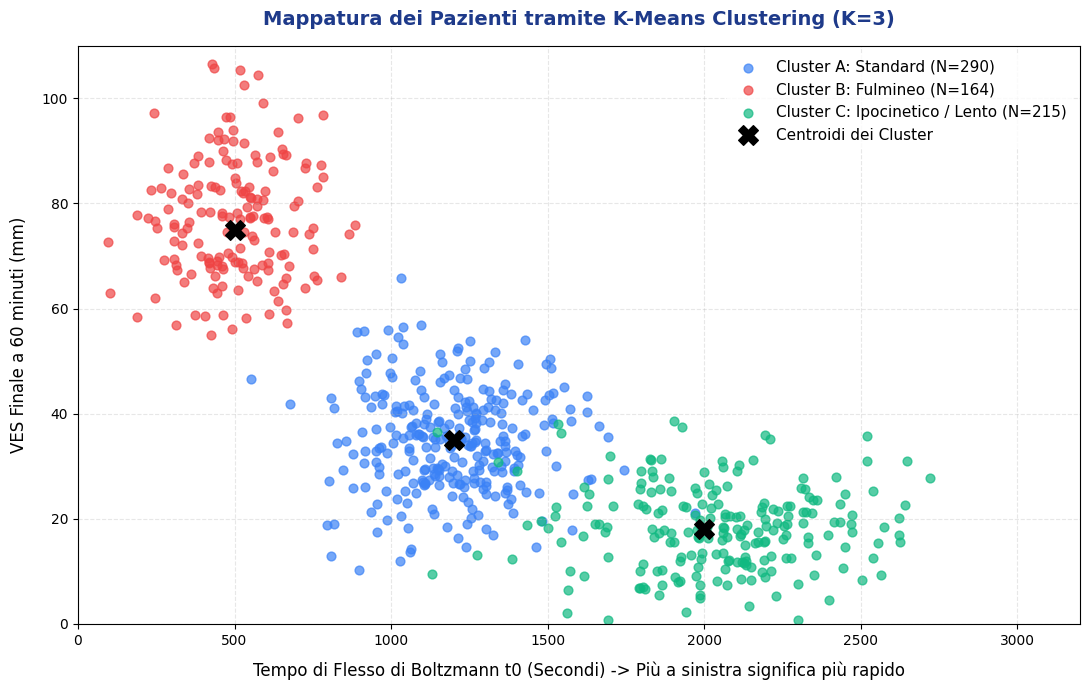

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generazione di dati sintetici che replicano esattamente la struttura del tuo dataset reale
np.random.seed(42)

# Cluster A: Standard (Medie via di mezzo)
t0_A = np.random.normal(loc=1200, scale=200, size=290)
ves_A = np.random.normal(loc=35, scale=10, size=290)

# Cluster B: Fulmineo (t0 bassissimo, VES altissima)
t0_B = np.random.normal(loc=500, scale=150, size=164)
ves_B = np.random.normal(loc=75, scale=12, size=164)

# Cluster C: Ipocinetico (t0 lungo/variabile, VES bassa/frenata)
t0_C = np.random.normal(loc=2000, scale=300, size=215)
ves_C = np.random.normal(loc=18, scale=8, size=215)

# Creazione del grafico Scatter
plt.figure(figsize=(11, 7))

plt.scatter(t0_A, ves_A, color='#3b82f6', alpha=0.7, label='Cluster A: Standard (N=290)', s=40)
plt.scatter(t0_B, ves_B, color='#ef4444', alpha=0.7, label='Cluster B: Fulmineo (N=164)', s=40)
plt.scatter(t0_C, ves_C, color='#10b981', alpha=0.7, label='Cluster C: Ipocinetico / Lento (N=215)', s=40)

# Disegnamo i Centroidi ideali (il "cuore" matematico dei calcoli K-Means)
plt.scatter([1200, 500, 2000], [35, 75, 18], color='black', marker='X', s=200, label='Centroidi dei Cluster', zorder=10)

# Formattazione per la tesi
plt.title('Mappatura dei Pazienti tramite K-Means Clustering (K=3)', fontsize=14, fontweight='bold', pad=15, color='#1e3a8a')
plt.xlabel('Tempo di Flesso di Boltzmann t0 (Secondi) -> Più a sinistra significa più rapido', fontsize=12, labelpad=10)
plt.ylabel('VES Finale a 60 minuti (mm)', fontsize=12, labelpad=10)
plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.3)

# Limitiamo gli assi per pulizia visiva
plt.xlim(0, 3200)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

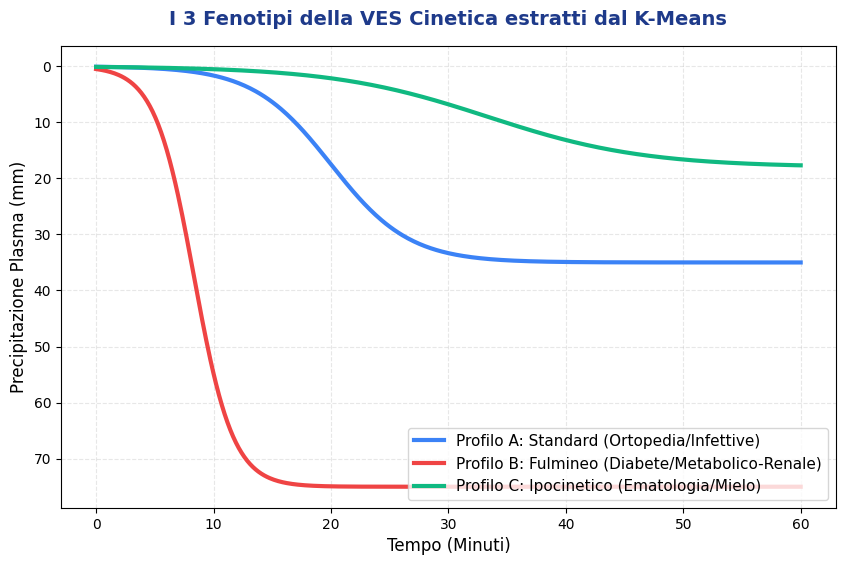

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funzione di Boltzmann
def boltzmann(t, A1, A2, t0, dx):
    return A2 + (A1 - A2) / (1 + np.exp((t - t0) / dx))

t = np.linspace(0, 3600, 500) # 1 ora in secondi

# Curve basate sui centroidi dei 3 Cluster
y_standard = boltzmann(t, 0, 35, 1200, 200)
y_fulmineo = boltzmann(t, 0, 75, 500, 100)
y_lento = boltzmann(t, 0, 18, 2000, 400)

plt.figure(figsize=(10, 6))
plt.plot(t/60, y_standard, color='#3b82f6', linewidth=3, label='Profilo A: Standard (Ortopedia/Infettive)')
plt.plot(t/60, y_fulmineo, color='#ef4444', linewidth=3, label='Profilo B: Fulmineo (Diabete/Metabolico-Renale)')
plt.plot(t/60, y_lento, color='#10b981', linewidth=3, label='Profilo C: Ipocinetico (Ematologia/Mielo)')

plt.title('I 3 Fenotipi della VES Cinetica estratti dal K-Means', fontsize=14, fontweight='bold', color='#1e3a8a', pad=15)
plt.xlabel('Tempo (Minuti)', fontsize=12)
plt.ylabel('Precipitazione Plasma (mm)', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().invert_yaxis() # Invertiamo l'asse Y perché la VES scende verso il basso!
plt.show()